# Timeline Analysis

In [34]:
import pandas as pd

twitter = pd.read_csv("../../../Data/Processed/Twitter_clean.csv")

twitter["time_bin"] = pd.to_datetime(twitter["time_bin"])

timeline = (
    twitter
    .groupby("time_bin")
    .agg(
        total_tweets=("id", "count"),
        original_tweets=("is_retweet", lambda x: (~x).sum()),
        retweets=("is_retweet", "sum")
    )
    .reset_index()
)

timeline

,time_bin,total_tweets,original_tweets,retweets
0,2019-04-23 09:20:00,558,62,496
1,2019-04-23 09:25:00,846,89,757
2,2019-04-23 09:30:00,863,90,773
3,2019-04-23 09:35:00,884,89,795
4,2019-04-23 09:40:00,936,92,844
5,2019-04-23 09:45:00,822,79,743
6,2019-04-23 09:50:00,959,90,869
7,2019-04-23 09:55:00,1038,93,945
8,2019-04-23 10:00:00,1018,98,920
9,2019-04-23 10:05:00,862,81,781


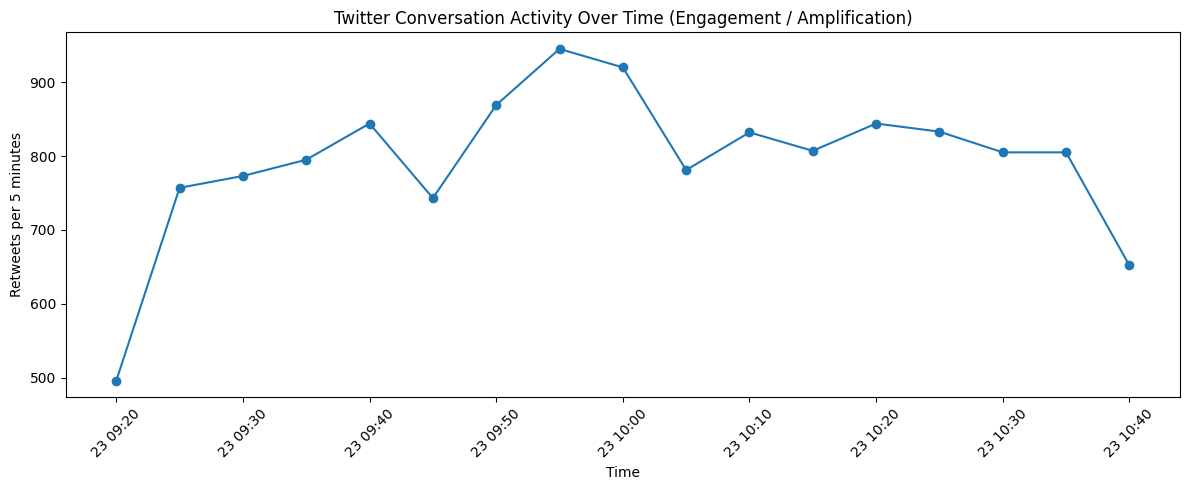

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    timeline["time_bin"],
    timeline["retweets"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Retweets per 5 minutes")
plt.title("Twitter Conversation Activity Over Time (Engagement / Amplification)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
timeline["retweet_ratio"] = (
    timeline["retweets"] / timeline["total_tweets"]
)

timeline["retweet_ratio"].describe()

count    17.000000
mean      0.900042
std       0.010591
min       0.881481
25%       0.894799
50%       0.901709
75%       0.906032
max       0.924823
Name: retweet_ratio, dtype: float64

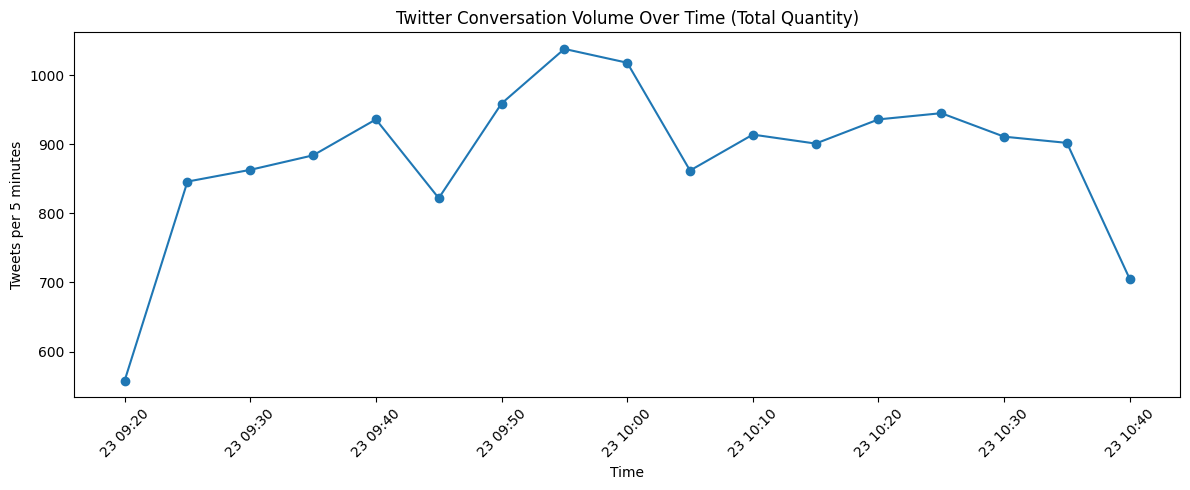

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    timeline["time_bin"],
    timeline["total_tweets"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Tweets per 5 minutes")
plt.title("Twitter Conversation Volume Over Time (Total Quantity)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

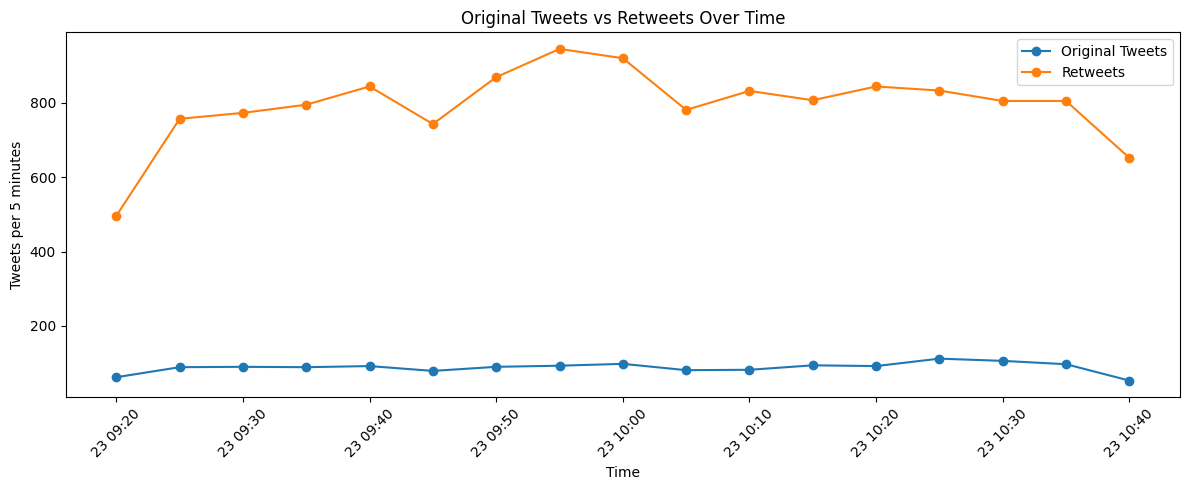

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    timeline["time_bin"],
    timeline["original_tweets"],
    marker="o",
    label="Original Tweets"
)

plt.plot(
    timeline["time_bin"],
    timeline["retweets"],
    marker="o",
    label="Retweets"
)

plt.xlabel("Time")
plt.ylabel("Tweets per 5 minutes")
plt.title("Original Tweets vs Retweets Over Time")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [39]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
scores = twitter["text_clean"].apply(analyzer.polarity_scores) # Runs the result of polarity_scores on every row in text_clean and saves it as a pandas series.

twitter["neg"] = scores.apply(lambda x: x["neg"]) # We pull out the neg from those dict (pandas series now) and we apply it to every row.
twitter["neu"] = scores.apply(lambda x: x["neu"])
twitter["pos"] = scores.apply(lambda x: x["pos"])
twitter["compound"] = scores.apply(lambda x: x["compound"]) # Overall: between -1 and 1.

In [40]:
def get_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [41]:
twitter["sentiment"] = twitter["compound"].apply(get_sentiment) # Produces a new column Sentiment applying all the values from the above function.

print(twitter["sentiment"].value_counts()) # Raw counts.
print(twitter["sentiment"].value_counts(normalize=True) * 100) # Percentages.

print(twitter[
    ["text_clean", "compound", "sentiment"]
].head(20))

originals = twitter[twitter["tweet_type"] == "original"]
originals["sentiment"].value_counts(normalize=True) * 100

sentiment
positive    8260
neutral     5371
negative    1369
Name: count, dtype: int64
sentiment
positive    55.066667
neutral     35.806667
negative     9.126667
Name: proportion, dtype: float64
                                           text_clean  compound sentiment
0   RT @mrvelstan: literally nobody: me: #Avengers...    0.0000   neutral
1   RT @agntecarter: i�m emotional, sorry!! 2014 x...    0.2225  positive
2   saving these bingo cards for tomorrow � #Aveng...    0.0000   neutral
3   RT @HelloBoon: Man these #AvengersEndgame ads ...    0.0000   neutral
4   RT @Marvel: We salute you, @ChrisEvans! #Capta...    0.4753  positive
5   RT @MCU_Direct: The first NON-SPOILER #Avenger...    0.4201  positive
6   RT @Renner4Real: Ready to rock ! #excited #ave...    0.6360  positive
7   RT @Avengers: We�re with him �til the end of t...    0.0000   neutral
8   RT @Variety: #AvengersEndgame first reactions:...    0.2247  positive
9   RT @HelloBoon: Man these #AvengersEndgame ads ...    0.0000 

sentiment
neutral     42.161441
positive    41.360907
negative    16.477652
Name: proportion, dtype: float64

In [42]:
sentiment_timeline = (
    twitter
    .groupby(["time_bin", "sentiment"]) # Converts the sentiments into columns.
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

sentiment_timeline

sentiment,time_bin,negative,neutral,positive
0,2019-04-23 09:20:00,45,199,314
1,2019-04-23 09:25:00,77,320,449
2,2019-04-23 09:30:00,64,312,487
3,2019-04-23 09:35:00,79,293,512
4,2019-04-23 09:40:00,79,337,520
5,2019-04-23 09:45:00,71,291,460
6,2019-04-23 09:50:00,89,319,551
7,2019-04-23 09:55:00,95,371,572
8,2019-04-23 10:00:00,107,333,578
9,2019-04-23 10:05:00,79,309,474


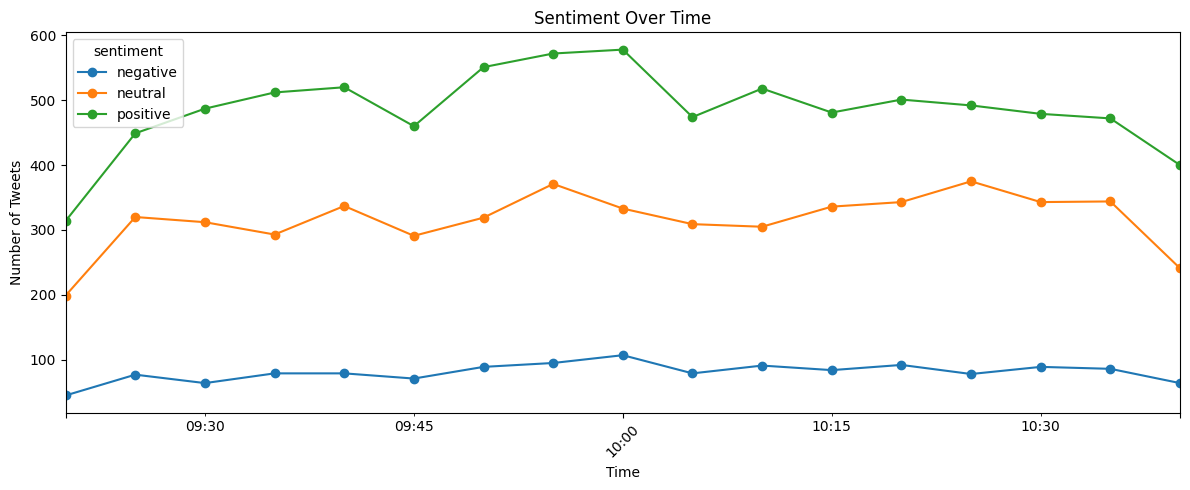

In [43]:
sentiment_timeline.set_index("time_bin").plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.title("Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
sentiment_pct = (
    twitter
    .groupby(["time_bin", "sentiment"])
    .size() # Counts tweets per pair (bin, sentiment). 

    .pipe(lambda s: s / s.groupby(level=0).transform("sum") * 100) # Percentage.
    .rename("percentage")
    .reset_index()
)

sentiment_pct

,time_bin,sentiment,percentage
0,2019-04-23 09:20:00,negative,8.064516
1,2019-04-23 09:20:00,neutral,35.663082
2,2019-04-23 09:20:00,positive,56.272401
3,2019-04-23 09:25:00,negative,9.101655
4,2019-04-23 09:25:00,neutral,37.825059
5,2019-04-23 09:25:00,positive,53.073286
6,2019-04-23 09:30:00,negative,7.415991
7,2019-04-23 09:30:00,neutral,36.152955
8,2019-04-23 09:30:00,positive,56.431054
9,2019-04-23 09:35:00,negative,8.936652


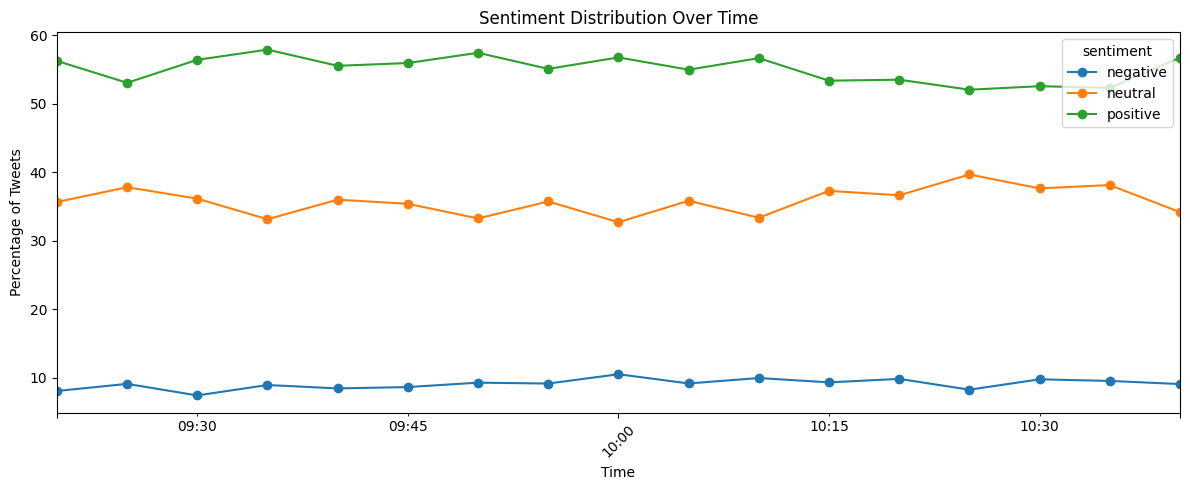

In [45]:
sentiment_pct_pivot = sentiment_pct.pivot(
    index="time_bin",
    columns="sentiment",
    values="percentage"
)

sentiment_pct_pivot.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Percentage of Tweets")
plt.title("Sentiment Distribution Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
sentiment_score_timeline = (
    twitter
    .groupby("time_bin")["compound"]
    .mean()
    .reset_index()
)

sentiment_score_timeline

,time_bin,compound
0,2019-04-23 09:20:00,0.283890
1,2019-04-23 09:25:00,0.258764
2,2019-04-23 09:30:00,0.290378
3,2019-04-23 09:35:00,0.295818
4,2019-04-23 09:40:00,0.292244
5,2019-04-23 09:45:00,0.277025
6,2019-04-23 09:50:00,0.290693
7,2019-04-23 09:55:00,0.277950
8,2019-04-23 10:00:00,0.278535
9,2019-04-23 10:05:00,0.275920


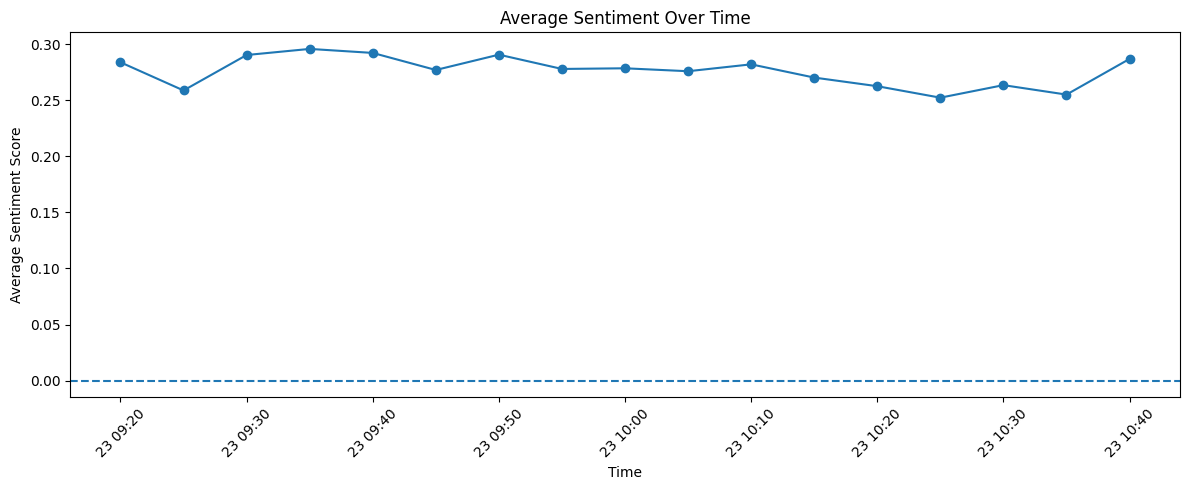

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    sentiment_score_timeline["time_bin"],
    sentiment_score_timeline["compound"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Average Sentiment Score")
plt.title("Average Sentiment Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()